# Case Study: Sampling Frequency and Masking Strategy Performance

This case study aims to examine whether sampling frequency affects the relative performance of zero masking vs. gaussian noise masking.

## Motivation
Initial experiments showed gaussian noise outperforms zero masking on ETTh1 (hourly) but underperforms on Weather (10-minute sampling) for short horizons. To validate whether higher sampling frequency favors zero masking, we test on:
- ETTm1: Same domain as ETTh1 but sampled every 15 minutes
- ETTh2: Same hourly sampling as ETTh1 but different electricity transformer

## 0. Get Setup

In [1]:
# Clone the github repo and download dependencies
!git clone https://github.com/chunyagi/PatchTST.git

Cloning into 'PatchTST'...
remote: Enumerating objects: 392, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 392 (delta 10), reused 14 (delta 8), pack-reused 361 (from 1)
Receiving objects: 100% (392/392), 12.95 MiB | 20.55 MiB/s, done.
Resolving deltas: 100% (173/173), done.


In [ ]:
# Install dependencies (uncomment it if you're using google colab)
# !pip install -r PatchTST/PatchTST_supervised/requirements.txt

In [2]:
# Traverse into the target directory
%cd /content/PatchTST/PatchTST_self_supervised

/content/PatchTST/PatchTST_self_supervised


## 1. Download Data

In [43]:
# Download data from google drive with gdown
try:
    import gdown
    print(f"[INFO] gdown version: {gdown.__version__}")
except:
    print("[INFO] Couldn't find gdown, installing it...")
    !pip install -q gdown
    import gdown
    print(f"[INFO] gdown version: {gdown.__version__}")

!mkdir -p /data/datasets/public/ETDataset/ETT-small
!gdown 1B7VcTWdIfPl3g17zKXATKF9XQJtNHTtl -O /data/datasets/public/ETDataset/ETT-small/
!gdown 1bOcmp9VAv03d3kUYSrttOFvLZ0keXDC5 -O /data/datasets/public/ETDataset/ETT-small/

[INFO] gdown version: 5.2.1
Downloading...
From: https://drive.google.com/uc?id=1B7VcTWdIfPl3g17zKXATKF9XQJtNHTtl
To: /data/datasets/public/ETDataset/ETT-small/ETTm1.csv
100% 10.4M/10.4M [00:00<00:00, 44.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bOcmp9VAv03d3kUYSrttOFvLZ0keXDC5
To: /data/datasets/public/ETDataset/ETT-small/ETTh2.csv
100% 2.42M/2.42M [00:00<00:00, 18.8MB/s]


## 2. ETTm1

We run both methods on ETTm1 with a single seed.

**Note**: Since ETTm1 has a higher sampling frequency (15-min intervals), we adjust the hyperparameters according to the original PatchTST paper to: `n_heads=16, d_model=128, d_ff=256`.

### 2.1 Zero Masking

In [15]:
# Pretraining
!python patchtst_pretrain.py --dset ettm1 --d_ff 256 --n_epochs_pretrain 100 --patient 7 --pretrained_model_id 3 --seed 2021

args: Namespace(dset_pretrain='ettm1', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, mask_ratio=0.4, use_gaussian_noise=0, noise_std=0.1, n_epochs_pretrain=100, patient=7, lr=0.0001, pretrained_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 406028
suggested_lr 0.00043287612810830566
number of patches: 42
number of model params 406028
          epoch     train_loss     valid_loss           time
Better model found at epoch 0 with valid_loss value: 0.962703176285558.
              0       0.987472       0.962703          00:20
              1       0.973144       0.963291          00:20
              2       0.970391       0.963472          00:20
              3       0.969088       0.963508          00:20
Better model found at epoch 4 with valid_loss value: 0.96221

In [5]:
# 96
!python patchtst_finetune.py --dset ettm1 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(dset_pretrain='ettm1', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, mask_ratio=0.4, use_gaussian_noise=0, noise_std=0.1, n_epochs_pretrain=100, patient=7, lr=0.0001, pretrained_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 406028
suggested_lr 0.00043287612810830566
number of patches: 42
number of model params 406028
          epoch     train_loss     valid_loss           time
Better model found at epoch 0 with valid_loss value: 0.962703176285558.
              0       0.987472       0.962703          00:19
              1       0.973144       0.963291          00:19
              2       0.970391       0.963472          00:20
              3       0.969088       0.963508          00:20
Better model found at epoch 4 with valid_loss value: 0.96221

In [17]:
# 192
!python patchtst_finetune.py --dset ettm1 --target_points 192 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='ettm1', context_points=512, target_points=192, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 1436864
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth successfully transferred!

suggested_lr 0.00017073526474706903
end-to-end finetuning
number of patches: 42
number of model params 1436864
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12

In [19]:
# 336
!python patchtst_finetune.py --dset ettm1 --target_points 336 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='ettm1', context_points=512, target_points=336, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 2211152
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth successfully transferred!

suggested_lr 6.73415065775082e-05
end-to-end finetuning
number of patches: 42
number of model params 2211152
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_e

In [16]:
# 720
!python patchtst_finetune.py --dset ettm1 --target_points 720 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='ettm1', context_points=512, target_points=720, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 4275920
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth successfully transferred!

suggested_lr 6.73415065775082e-05
end-to-end finetuning
number of patches: 42
number of model params 4275920
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_e

### 2.2 Gaussian Noise Addition

In [ ]:
# Pretraining
!python patchtst_pretrain.py --dset ettm1 --d_ff 256 --use_gaussian_noise 1 --noise_std 0.1 --n_epochs_pretrain 100 --patient 7 --pretrained_model_id 3 --seed 2021

In [9]:
# 96
!python patchtst_finetune.py --dset ettm1 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(dset_pretrain='ettm1', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, mask_ratio=0.4, use_gaussian_noise=1, noise_std=0.1, n_epochs_pretrain=100, patient=7, lr=0.0001, pretrained_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 406028
suggested_lr 0.0006280291441834253
number of patches: 42
number of model params 406028
          epoch     train_loss     valid_loss           time
Better model found at epoch 0 with valid_loss value: 0.029109207253487417.
              0       0.404626       0.029109          00:19
Better model found at epoch 1 with valid_loss value: 0.01650940609186953.
              1       0.148666       0.016509          00:20
Better model found at epoch 2 with valid_loss value: 0.013067807253914798.
              2       0.115769 

In [18]:
# 192
!python patchtst_finetune.py --dset ettm1 --target_points 192 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='ettm1', context_points=512, target_points=192, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 1436864
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth successfully transferred!

suggested_lr 0.0002477076355991711
end-to-end finetuning
number of patches: 42
number of model params 1436864
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12

In [20]:
# 336
!python patchtst_finetune.py --dset ettm1 --target_points 336 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='ettm1', context_points=512, target_points=336, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 2211152
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth successfully transferred!

suggested_lr 6.73415065775082e-05
end-to-end finetuning
number of patches: 42
number of model params 2211152
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_

In [14]:
# 720
!python patchtst_finetune.py --dset ettm1 --target_points 720 --d_ff 256 --pretrained_model ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='ettm1', context_points=512, target_points=720, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=16, d_model=128, d_ff=256, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 4275920
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth successfully transferred!

suggested_lr 6.73415065775082e-05
end-to-end finetuning
number of patches: 42
number of model params 4275920
weights from ./saved_models/ettm1/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_

In [71]:
# Collect the results in a dataframe
import pandas as pd

df = pd.DataFrame({
    'Zero_MSE': [0.287, 0.329, 0.359, 0.422],
    'Zero_MAE': [0.342, 0.372, 0.387, 0.420],
    'Gaussian_MSE': [0.292, 0.343, 0.360, 0.405],
    'Gaussian_MAE': [0.348, 0.377, 0.392, 0.421]
}, index=[96, 192, 336, 720])
df.index.name = 'Horizon'
df

,Zero_MSE,Zero_MAE,Gaussian_MSE,Gaussian_MAE
Horizon,,,,
96,0.287,0.342,0.292,0.348
192,0.329,0.372,0.343,0.377
336,0.359,0.387,0.360,0.392
720,0.422,0.420,0.405,0.421


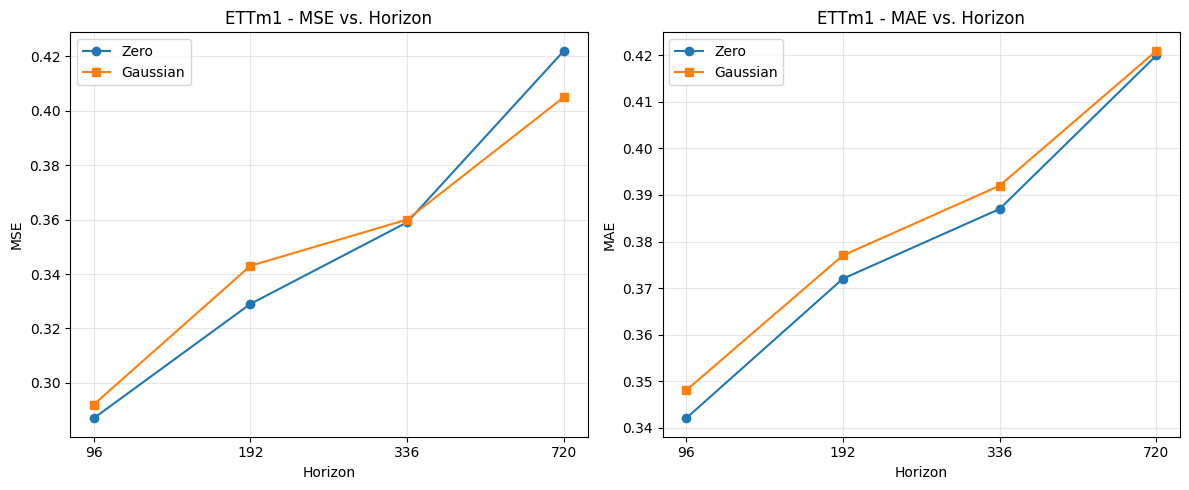

In [73]:
# Create subplots
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x = range(len(df.index))  # Even spacing: 0, 1, 2, 3

# MSE subplot
ax1.plot(x, df['Zero_MSE'], marker='o', label='Zero')
ax1.plot(x, df['Gaussian_MSE'], marker='s', label='Gaussian')
ax1.set_xlabel('Horizon')
ax1.set_ylabel('MSE')
ax1.set_title('ETTm1 - MSE vs. Horizon')
ax1.set_xticks(x)
ax1.set_xticklabels(df.index)
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE subplot
ax2.plot(x, df['Zero_MAE'], marker='o', label='Zero')
ax2.plot(x, df['Gaussian_MAE'], marker='s', label='Gaussian')
ax2.set_xlabel('Horizon')
ax2.set_ylabel('MAE')
ax2.set_title('ETTm1 - MAE vs. Horizon')
ax2.set_xticks(x)
ax2.set_xticklabels(df.index)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. ETTh2

### 3.1 Zero Masking

In [48]:
# Pretraining
!python patchtst_pretrain.py --dset etth2 --n_heads 4 --d_model 16 --d_ff 128 --n_epochs_pretrain 100 --patient 100 --pretrained_model_id 3 --seed 2021

args: Namespace(dset_pretrain='etth2', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, mask_ratio=0.4, use_gaussian_noise=0, noise_std=0.1, n_epochs_pretrain=100, patient=100, lr=0.0001, pretrained_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 17260
suggested_lr 0.0027825594022071257
number of patches: 42
number of model params 17260
          epoch     train_loss     valid_loss           time
Better model found at epoch 0 with valid_loss value: 0.9878370630890934.
              0       1.027362       0.987837          00:01
Better model found at epoch 1 with valid_loss value: 0.9835181847508977.
              1       0.988593       0.983518          00:01
Better model found at epoch 2 with valid_loss value: 0.9759899748934021.
              2       0.977871       0

In [49]:
# 96
!python patchtst_finetune.py --dset etth2 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 81664
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth successfully transferred!

suggested_lr 0.0027825594022071257
end-to-end finetuning
number of patches: 42
number of model params 81664
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-

In [52]:
# 192
!python patchtst_finetune.py --dset etth2 --target_points 192 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=192, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 146272
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth successfully transferred!

suggested_lr 0.014849682622544665
end-to-end finetuning
number of patches: 42
number of model params 146272
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epoch

In [53]:
# 336
!python patchtst_finetune.py --dset etth2 --target_points 336 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=336, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 243184
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth successfully transferred!

suggested_lr 0.002310129700083158
end-to-end finetuning
number of patches: 42
number of model params 243184
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epoch

In [54]:
# 720
!python patchtst_finetune.py --dset etth2 --target_points 720 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=720, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 501616
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_zero_model3.pth successfully transferred!

suggested_lr 0.004037017258596558
end-to-end finetuning
number of patches: 42
number of model params 501616
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epoch

### 3.2 Gaussian Noise Addition

In [50]:
# Pretraining
!python patchtst_pretrain.py --dset etth2 --n_heads 4 --d_model 16 --d_ff 128 --use_gaussian_noise 1 --noise_std 0.1 --n_epochs_pretrain 100 --patient 100 --pretrained_model_id 3 --seed 2021

args: Namespace(dset_pretrain='etth2', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, mask_ratio=0.4, use_gaussian_noise=1, noise_std=0.1, n_epochs_pretrain=100, patient=100, lr=0.0001, pretrained_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 17260
suggested_lr 0.0006280291441834253
number of patches: 42
number of model params 17260
          epoch     train_loss     valid_loss           time
Better model found at epoch 0 with valid_loss value: 1.0267462410233392.
              0       1.313284       1.026746          00:01
Better model found at epoch 1 with valid_loss value: 0.8622960088925045.
              1       1.121676       0.862296          00:01
Better model found at epoch 2 with valid_loss value: 0.7035928120090889.
              2       0.948998       0

In [51]:
# 96
!python patchtst_finetune.py --dset etth2 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=96, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 81664
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth successfully transferred!

suggested_lr 0.004862601580065354
end-to-end finetuning
number of patches: 42
number of model params 81664
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride1

In [55]:
# 192
!python patchtst_finetune.py --dset etth2 --target_points 192 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=192, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 146272
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth successfully transferred!

suggested_lr 0.004862601580065354
end-to-end finetuning
number of patches: 42
number of model params 146272
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stri

In [56]:
# 336
!python patchtst_finetune.py --dset etth2 --target_points 336 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=336, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 243184
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth successfully transferred!

suggested_lr 0.001917910261672489
end-to-end finetuning
number of patches: 42
number of model params 243184
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stri

In [57]:
# 720
!python patchtst_finetune.py --dset etth2 --target_points 720 --n_heads 4 --d_model 16 --d_ff 128 --pretrained_model ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth --is_finetune 1 --finetuned_model_id 3 --seed 2021

args: Namespace(is_finetune=1, is_linear_probe=0, dset_finetune='etth2', context_points=512, target_points=720, batch_size=64, num_workers=0, scaler='standard', features='M', percent=100, patch_len=12, stride=12, revin=1, affine=0, n_layers=3, n_heads=4, d_model=16, d_ff=128, dropout=0.2, head_dropout=0.2, n_epochs_finetune=20, lr=0.0001, pretrained_model='./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth', finetuned_model_id=3, model_type='based_model', seed=2021)
number of patches: 42
number of model params 501616
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_stride12_epochs-pretrain100_mask0.4_gnoise0.1_model3.pth successfully transferred!

suggested_lr 0.0013219411484660286
end-to-end finetuning
number of patches: 42
number of model params 501616
weights from ./saved_models/etth2/masked_patchtst/based_model/patchtst_pretrained_cw512_patch12_str

In [64]:
# Collect the results in a dataframe
df = pd.DataFrame({
    'Zero_MSE': [0.295, 0.369, 0.377, 0.403],
    'Zero_MAE': [0.350, 0.394, 0.409, 0.434],
    'Gaussian_MSE': [0.266, 0.328, 0.355, 0.385],
    'Gaussian_MAE': [0.331, 0.374, 0.397, 0.426]
}, index=[96, 192, 336, 720])
df.index.name = 'Horizon'
df

,Zero_MSE,Zero_MAE,Gaussian_MSE,Gaussian_MAE
Horizon,,,,
96,0.295,0.350,0.266,0.331
192,0.369,0.394,0.328,0.374
336,0.377,0.409,0.355,0.397
720,0.403,0.434,0.385,0.426


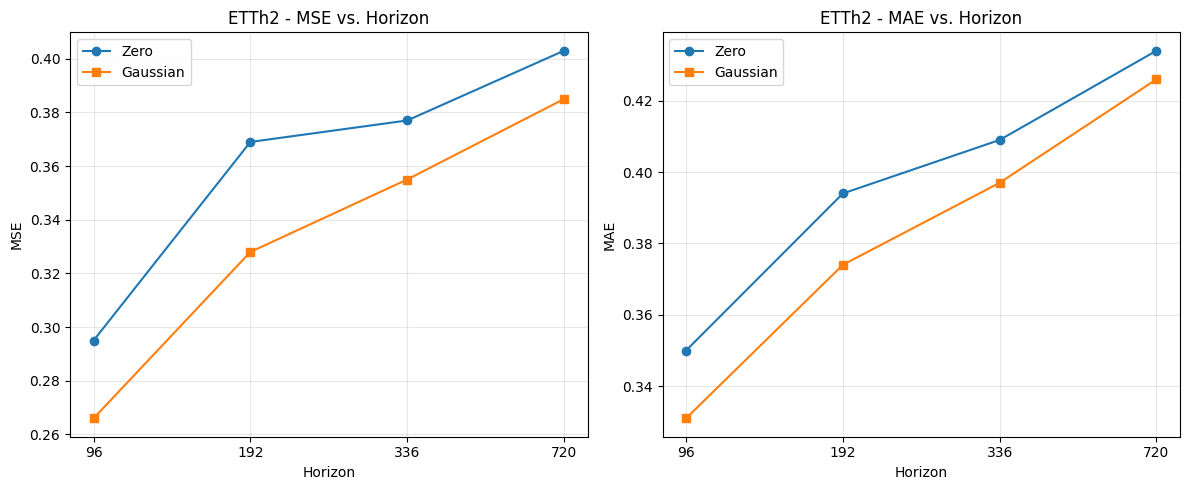

In [69]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x = range(len(df.index))  # Even spacing: 0, 1, 2, 3

# MSE subplot
ax1.plot(x, df['Zero_MSE'], marker='o', label='Zero')
ax1.plot(x, df['Gaussian_MSE'], marker='s', label='Gaussian')
ax1.set_xlabel('Horizon')
ax1.set_ylabel('MSE')
ax1.set_title('ETTh2 - MSE vs. Horizon')
ax1.set_xticks(x)
ax1.set_xticklabels(df.index)
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE subplot
ax2.plot(x, df['Zero_MAE'], marker='o', label='Zero')
ax2.plot(x, df['Gaussian_MAE'], marker='s', label='Gaussian')
ax2.set_xlabel('Horizon')
ax2.set_ylabel('MAE')
ax2.set_title('ETTh2 - MAE vs. Horizon')
ax2.set_xticks(x)
ax2.set_xticklabels(df.index)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()